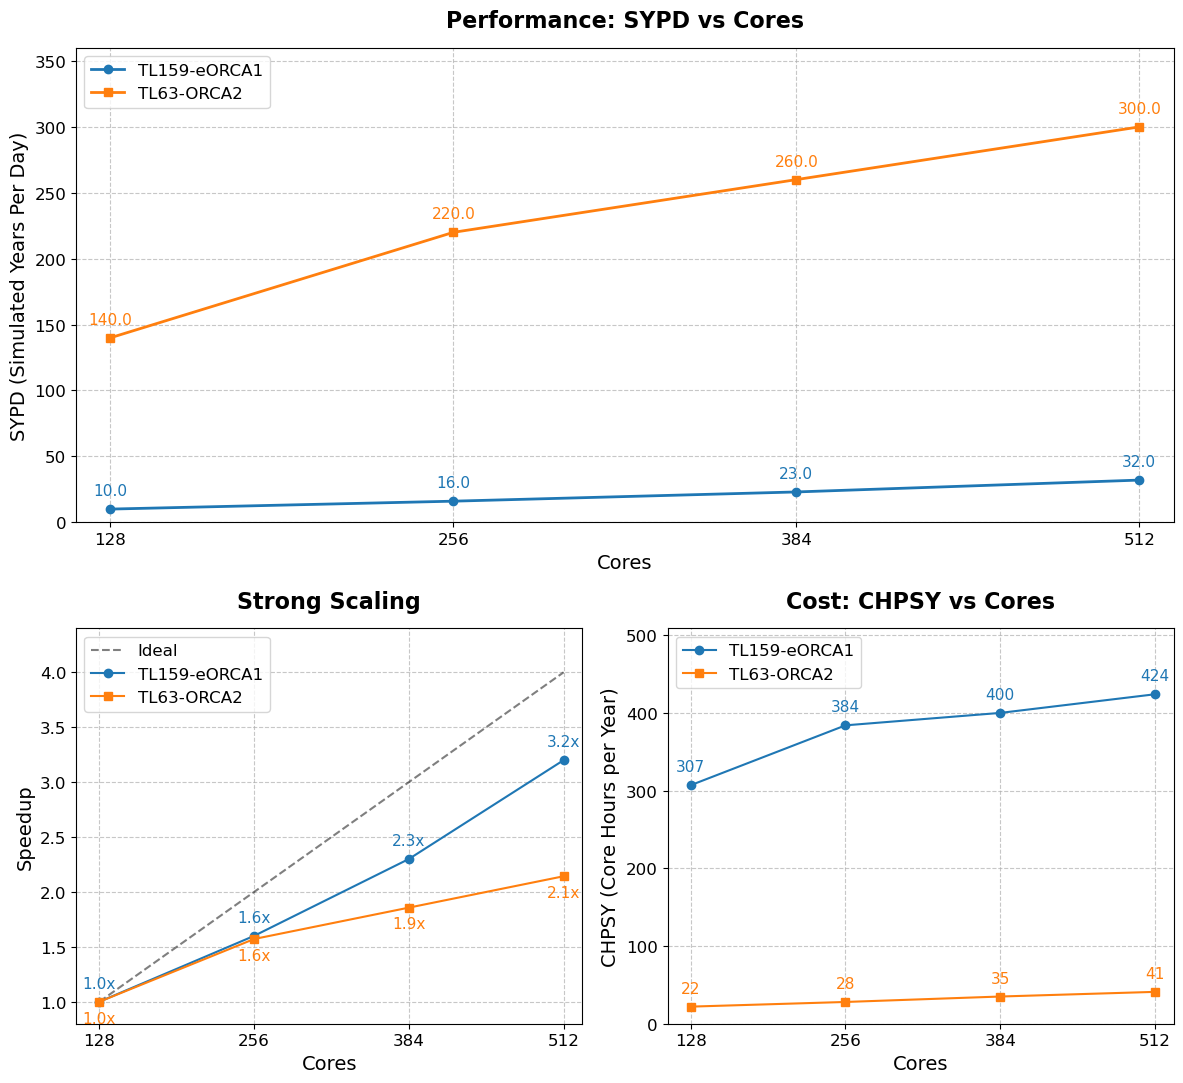

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- DATI ---
cores = np.array([128, 256, 384, 512])

# SYPD
sypd_tl159 = np.array([10.0, 16.0, 23.0, 32.0])
sypd_tl63 = np.array([140.0, 220.0, 260.0, 300.0])

# CHPSY
chpsy_tl159 = np.array([307.0, 384.0, 400.0, 424.0])
chpsy_tl63 = np.array([22.0, 28.0, 35.0, 41.0])

# Strong Scaling (Speedup Relativo)
speedup_tl159 = sypd_tl159 / sypd_tl159[0]
speedup_tl63 = sypd_tl63 / sypd_tl63[0]
ideal_scaling = cores / cores[0]

# --- LAYOUT ---
fig = plt.figure(figsize=(12, 11))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1]) 

plt.rcParams.update({'font.size': 12})          # Dimensione base per tutto
plt.rcParams.update({'axes.titlesize': 16})     # Titoli dei singoli plot
plt.rcParams.update({'axes.labelsize': 14})     # Etichette X e Y
plt.rcParams.update({'xtick.labelsize': 12})    # Numeri sui tick
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})    # Legenda

def format_ax(ax, title, ylabel, x_data):
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15) # Aumentato fontsize e padding
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel('Cores', fontsize=14)
    ax.set_xticks(x_data) 
    ax.tick_params(axis='both', which='major', labelsize=12) # Ticks più visibili
    ax.grid(True, ls='--', alpha=0.7)
    ax.set_xlim(min(x_data)*0.85, max(x_data)*1.05)

# 1. PLOT SYPD (Principale)
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(cores, sypd_tl159, 'o-', lw=2, label='TL159-eORCA1', color='tab:blue')
ax0.plot(cores, sypd_tl63, 's-', lw=2, label='TL63-ORCA2', color='tab:orange')
format_ax(ax0, 'Performance: SYPD vs Cores', 'SYPD (Simulated Years Per Day)', cores)
ax0.set_ylim(0, max(sypd_tl63) * 1.2)
ax0.set_xlim(min(cores)*0.9, max(cores)*1.025)
ax0.legend()

for i, txt in enumerate(sypd_tl63):
    ax0.annotate(f'{txt:.1f}', (cores[i], sypd_tl63[i]), fontsize=11, textcoords="offset points", xytext=(0,10), ha='center', color='tab:orange')
for i, txt in enumerate(sypd_tl159):
    ax0.annotate(f'{txt:.1f}', (cores[i], sypd_tl159[i]), fontsize=11, textcoords="offset points", xytext=(0,10), ha='center', color='tab:blue')

# 2. PLOT STRONG SCALING (Basso a sinistra)
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(cores, ideal_scaling, 'k--', alpha=0.5, label='Ideal')
ax1.plot(cores, speedup_tl159, 'o-', color='tab:blue', label='TL159-eORCA1')
ax1.plot(cores, speedup_tl63, 's-', color='tab:orange', label='TL63-ORCA2')
format_ax(ax1, 'Strong Scaling', 'Speedup', cores)
ax1.set_ylim(0.8, max(ideal_scaling) * 1.1)
ax1.set_xlim(min(cores)*0.85, max(cores)*1.03)
ax1.legend()

# Numerini Speedup (x)
for i, txt in enumerate(speedup_tl159):
    ax1.annotate(f'{txt:.1f}x', (cores[i], speedup_tl159[i]), fontsize=11, textcoords="offset points", xytext=(0,10), ha='center', color='tab:blue')
for i, txt in enumerate(speedup_tl63):
    ax1.annotate(f'{txt:.1f}x', (cores[i], speedup_tl63[i]), fontsize=11, textcoords="offset points", xytext=(0,-15), ha='center', color='tab:orange')

# 3. PLOT CHPSY (Basso a destra)
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(cores, chpsy_tl159, 'o-', color='tab:blue', label='TL159-eORCA1')
ax2.plot(cores, chpsy_tl63, 's-', color='tab:orange', label='TL63-ORCA2')
format_ax(ax2, 'Cost: CHPSY vs Cores', 'CHPSY (Core Hours per Year)', cores)
ax2.set_ylim(0, max(chpsy_tl159) * 1.2)
ax2.set_xlim(min(cores)*0.85, max(cores)*1.03)
ax2.legend()

# Numerini CHPSY
for i, txt in enumerate(chpsy_tl159):
    ax2.annotate(f'{txt:.0f}', (cores[i], chpsy_tl159[i]), fontsize=11, textcoords="offset points", xytext=(0,10), ha='center', color='tab:blue')
for i, txt in enumerate(chpsy_tl63):
    ax2.annotate(f'{txt:.0f}', (cores[i], chpsy_tl63[i]),  fontsize=11, textcoords="offset points", xytext=(0,10), ha='center', color='tab:orange')

plt.tight_layout()
plt.show()